# Phase 1 — Data Pipeline

Pulls two years of GB market data from public APIs and saves to `data/raw/`.

| Step | Source | Output file |
|------|--------|-------------|
| 1 | Elexon BMRS | `elexon_da_prices.parquet` — half-hourly day-ahead prices |
| 2 | Elexon BMRS | `elexon_sp_prices.parquet` — half-hourly System Price (cash-out) |
| 3 | NESO Data Portal | `neso_eac_clearing.parquet` — EAC ancillary clearing by product |
| 4 | ICE/EEX or synthetic | `ice_eex_forwards.parquet` — GB baseload forward curve |

**Run cells top to bottom.** Step 3 may return empty if NESO resource IDs have changed — see note in that cell.

In [2]:
import sys, os

# Resolve project root (one level up from notebooks/)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print('Project root:', PROJECT_ROOT)

import subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'requests', 'pandas', 'pyarrow', 'matplotlib', '--quiet'])

Project root: g:\My Drive\Research\bess_project


CompletedProcess(args=['c:\\Users\\User\\AppData\\Local\\Programs\\Python\\Python312\\python.exe', '-m', 'pip', 'install', 'requests', 'pandas', 'pyarrow', 'matplotlib', '--quiet'], returncode=0)

In [3]:
from datetime import date
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

START = date(2024, 4, 1)   # 2 years of history for calibration
END   = date(2026, 4, 25)

RAW_DIR = Path(PROJECT_ROOT) / 'data' / 'raw'
RAW_DIR.mkdir(parents=True, exist_ok=True)

print(f'Fetching: {START} to {END}')
print(f'Output:   {RAW_DIR}')

Fetching: 2024-04-01 to 2026-04-25
Output:   g:\My Drive\Research\bess_project\data\raw


## Step 1 — Elexon day-ahead prices (MID)

Market Index Data — volume-weighted N2EX + EPEX half-hourly index.  
Public API, no credentials required.  
**Expected**: ~35,000 rows (2 years x 365 days x 48 HH periods)

In [4]:
from src.data.fetch_elexon import fetch_mid_range

da_path = RAW_DIR / 'elexon_da_prices.parquet'
df_da   = fetch_mid_range(START, END, out_path=da_path)

print(f'Rows: {len(df_da):,}')
df_da.head(8)

  MID  fetched up to 2026-04-25  (62,163 rows)
  MID: 31,164 rows across 755 days.
  Saved → g:\My Drive\Research\bess_project\data\raw\elexon_da_prices.parquet
Rows: 31,164


,settlement_date,settlement_period,price_gbp_mwh
0,2024-04-01,3,12.595
1,2024-04-01,4,16.800
2,2024-04-01,5,23.770
3,2024-04-01,6,22.325
4,2024-04-01,7,23.680
5,2024-04-01,8,26.470
6,2024-04-01,9,27.670
7,2024-04-01,10,28.130


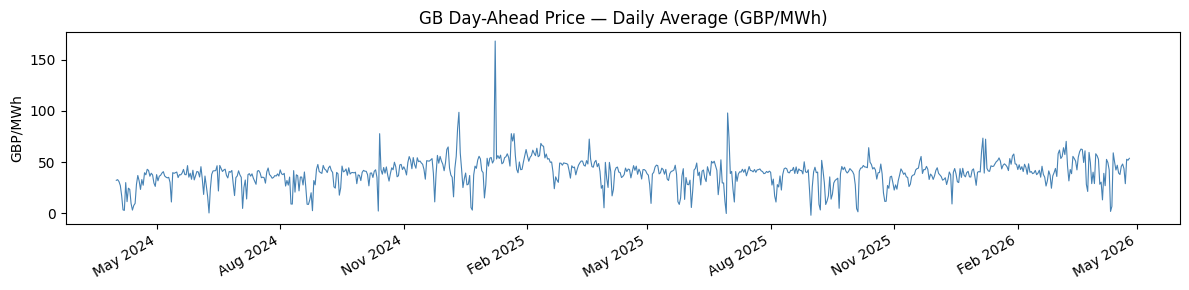

2025 DA:  mean=41.2  std=21.2  min=-80.6  max=676.5
Negative price HHs: 724 (model needs arithmetic OU, not log-normal)


In [5]:
if not df_da.empty:
    daily = df_da.groupby('settlement_date')['price_gbp_mwh'].mean()
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(daily.index, daily.values, lw=0.8, color='steelblue')
    ax.set(title='GB Day-Ahead Price — Daily Average (GBP/MWh)', ylabel='GBP/MWh')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

    y2025 = df_da[df_da['settlement_date'].dt.year == 2025]['price_gbp_mwh']
    print(f'2025 DA:  mean={y2025.mean():.1f}  std={y2025.std():.1f}  min={y2025.min():.1f}  max={y2025.max():.1f}')
    print(f'Negative price HHs: {(df_da["price_gbp_mwh"] < 0).sum()} (model needs arithmetic OU, not log-normal)')

## Step 2 — Elexon System Price (imbalance / cash-out)

System Price is the cash-out price for energy imbalance.  
Used to compute the DA-SP basis delta_t for OU+jump imbalance calibration.  
**Expected**: ~35,000 rows with `system_sell_price`, `system_buy_price`, `net_imbalance_volume`

In [6]:
from src.data.fetch_elexon import fetch_system_prices_range

sp_path = RAW_DIR / 'elexon_sp_prices.parquet'
df_sp   = fetch_system_prices_range(START, END, out_path=sp_path)

print(f'Rows: {len(df_sp):,}')
df_sp.head(6)

  SP  2026-04-25  (755/755 days, 36,240 rows)
  SP: 36,240 rows across 755 days.
  Saved → g:\My Drive\Research\bess_project\data\raw\elexon_sp_prices.parquet
Rows: 36,240


,settlement_date,settlement_period,system_sell_price,system_buy_price,system_price,net_imbalance_volume
0,2024-04-01,1,25.050000,25.050000,25.050000,-339.064440
1,2024-04-01,2,25.650000,25.650000,25.650000,-230.773426
2,2024-04-01,3,23.990000,23.990000,23.990000,-66.013667
3,2024-04-01,4,76.000000,76.000000,76.000000,143.783160
4,2024-04-01,5,73.384327,73.384327,73.384327,27.688429
5,2024-04-01,6,18.170000,18.170000,18.170000,-151.031493


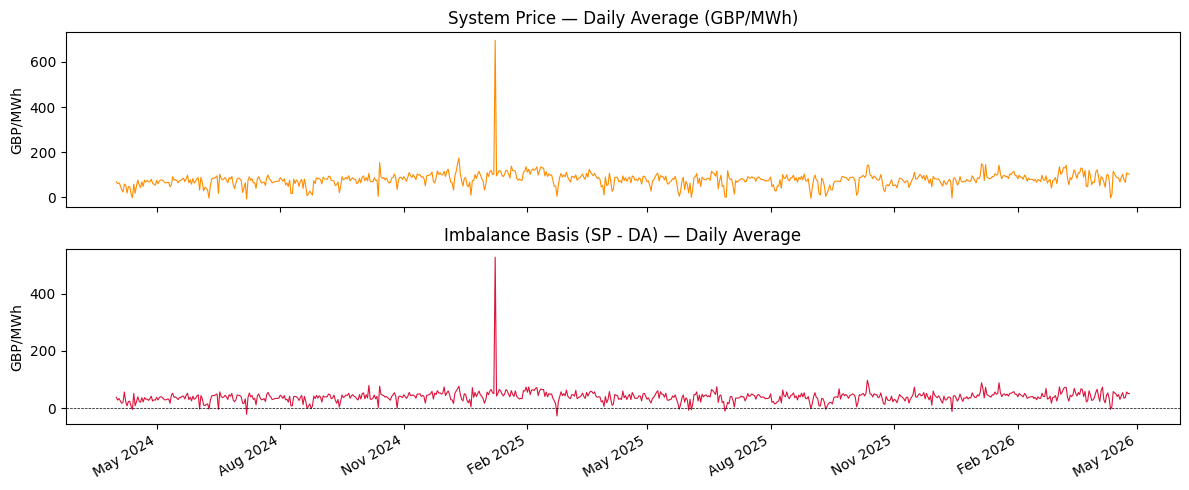

Imbalance basis stats (GBP/MWh):
count    31164.0
mean        40.2
std         51.0
min       -181.1
25%         21.2
50%         38.8
75%         62.3
max       2464.0
Name: imbalance_basis, dtype: float64
Jump HHs (|basis|>100): 373


In [7]:
if not df_sp.empty and not df_da.empty:
    merged = df_da[['settlement_date','settlement_period','price_gbp_mwh']].merge(
        df_sp[['settlement_date','settlement_period','system_price','net_imbalance_volume']],
        on=['settlement_date','settlement_period'], how='inner'
    )
    merged['imbalance_basis'] = merged['system_price'] - merged['price_gbp_mwh']

    fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
    axes[0].plot(merged.groupby('settlement_date')['system_price'].mean(), lw=0.8, color='darkorange')
    axes[0].set(title='System Price — Daily Average (GBP/MWh)', ylabel='GBP/MWh')
    axes[1].plot(merged.groupby('settlement_date')['imbalance_basis'].mean(), lw=0.8, color='crimson')
    axes[1].axhline(0, color='k', lw=0.5, ls='--')
    axes[1].set(title='Imbalance Basis (SP - DA) — Daily Average', ylabel='GBP/MWh')
    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

    print('Imbalance basis stats (GBP/MWh):')
    print(merged['imbalance_basis'].describe().round(1))
    print(f'Jump HHs (|basis|>100): {(merged["imbalance_basis"].abs()>100).sum()}')

## Step 3 — NESO EAC ancillary clearing

DC / DM / DR clearing prices by EFA block. QR from December 2024. BR from March 2024.

> **If this returns empty:** NESO reorganised dataset URLs in late 2024.  
> Go to https://api.nationalgrideso.com, search the product name (e.g. *Dynamic Containment EFA*),  
> copy the resource ID from the dataset URL, update `RESOURCE_IDS` in `src/data/fetch_neso.py`.  
> Fallback: download the CSV manually, then run:  
> `pd.read_csv('dc.csv').to_parquet('data/raw/neso_eac_clearing.parquet')`

In [8]:
from src.data.fetch_neso import fetch_all_ancillary

anc_path = RAW_DIR / 'neso_eac_clearing.parquet'
df_anc   = fetch_all_ancillary(START.isoformat(), END.isoformat(), out_path=anc_path)

print(f'Rows: {len(df_anc):,}')
if not df_anc.empty:
    print(df_anc.groupby('product')['clearing_price_gbp_mwh']
               .agg(['count','mean','min','max']).round(2))
else:
    print('Empty — update NESO resource IDs in src/data/fetch_neso.py')
    print('See: https://api.nationalgrideso.com')

  DC: no data — update RESOURCE_IDS in fetch_neso.py
  DM: no data — update RESOURCE_IDS in fetch_neso.py
  DR: no data — update RESOURCE_IDS in fetch_neso.py
  QR: no data — update RESOURCE_IDS in fetch_neso.py
  BR: no data — update RESOURCE_IDS in fetch_neso.py


ValueError: No objects to concatenate

In [ ]:
if not df_anc.empty and 'DC' in df_anc['product'].values:
    dc_daily = df_anc[df_anc['product']=='DC'].groupby('date')['clearing_price_gbp_mwh'].mean()
    fig, ax  = plt.subplots(figsize=(12, 3))
    ax.plot(dc_daily.index, dc_daily.values, lw=0.8, color='teal')
    ax.axhline(17, color='gray', lw=0.8, ls='--', label='2020-21 flat cap £17/MW/h')
    ax.set(title='Dynamic Containment — Average Clearing Price (GBP/MW/h)', ylabel='GBP/MW/h')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

## Step 4 — Forward curve

Synthetic for now, anchored to £76.7/MWh (KYOS Feb 2026 GB 10yr baseload).  

**To replace with real forwards:**  
- ICE WebICE: export GB Power monthly settlements, then run:  
  `python -m src.data.fetch_forwards --source ice --file <path>`  
- EEX transparency platform:  
  `python -m src.data.fetch_forwards --source eex --file <path>`

In [ ]:
from src.data.fetch_forwards import build_synthetic_forwards

fwd_path = RAW_DIR / 'ice_eex_forwards.parquet'
df_fwd   = build_synthetic_forwards(as_of=END)
df_fwd.to_parquet(fwd_path, index=False)

print('Synthetic forward curve:')
display(df_fwd[['contract','delivery_start','price_gbp_mwh','source']])

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(df_fwd['delivery_start'], df_fwd['price_gbp_mwh'], 'o-', color='navy', ms=5, lw=1.2)
ax.axhline(76.7, color='gray', lw=0.8, ls='--', label='KYOS anchor £76.7/MWh')
ax.set(title='GB Baseload Forward Curve (synthetic — replace with ICE/EEX)', ylabel='GBP/MWh')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

## Validation Summary

In [ ]:
print('=' * 55)
print('PHASE 1 VALIDATION SUMMARY')
print('=' * 55)

checks = {
    'elexon_da_prices.parquet':  100,
    'elexon_sp_prices.parquet':  100,
    'neso_eac_clearing.parquet':   0,
    'ice_eex_forwards.parquet':    1,
}

all_ok = True
for name, min_rows in checks.items():
    path = RAW_DIR / name
    if path.exists():
        n   = len(pd.read_parquet(path))
        ok  = n >= min_rows
        sym = 'OK  ' if ok else 'WARN'
        print(f'  [{sym}]  {name}: {n:,} rows')
        if not ok: all_ok = False
    else:
        print(f'  [FAIL]  {name}: MISSING'); all_ok = False

da_file = RAW_DIR / 'elexon_da_prices.parquet'
if da_file.exists():
    df_chk = pd.read_parquet(da_file)
    if not df_chk.empty:
        m25 = df_chk[df_chk['settlement_date'].dt.year==2025]['price_gbp_mwh'].mean()
        neg = (df_chk['price_gbp_mwh'] < 0).sum()
        print(f'\n  DA mean 2025:  £{m25:.1f}/MWh  (SS anchor: £76.7)')
        print(f'  Negative HHs:  {neg}  (arithmetic OU required, not log-normal)')

print('\nRESULT:', 'All files present — ready for Phase 2 calibration'
      if all_ok else 'Some files missing — see notes above')
print('Next: notebooks/02_calibration.ipynb')